<a href="https://colab.research.google.com/github/Bmartins25/Vigilancia_One_Health_Estratificao_de_Risco_Esquistossomose/blob/main/An%C3%A1lise_sint%C3%A9tica_Projeto_Africa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ============================================================
# ANÁLISE COMPLETA - ESQUISTOSSOMOSE
# Base sintética com 1.500 registros
# Compatível com Google Colab
# ============================================================
#
# Este script:
# 1) carrega a base Excel existente;
# 2) valida a estrutura dos dados;
# 3) gera estatística descritiva;
# 4) realiza análise inferencial;
# 5) treina modelos de Machine Learning;
# 6) calcula métricas de desempenho;
# 7) calcula importância das variáveis;
# 8) gera estratos de risco;
# 9) exporta todos os resultados para Excel;
# 10) gera visualizações gráficas em PNG (300 dpi).
#
# IMPORTANTE:
# - A base é sintética e serve para demonstração metodológica.
# - Os resultados não representam desempenho clínico validado.
#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance


# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

RANDOM_STATE = 42

BASE_DIR = Path("/content")
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Nome esperado do arquivo
ARQUIVO_EXCEL = BASE_DIR / "base_sintetica_esquistossomose_1500.xlsx"

# Se o arquivo não estiver com esse nome, o script procura
# automaticamente por outro .xlsx dentro de /content.
if not ARQUIVO_EXCEL.exists():
    candidatos = [
        p for p in BASE_DIR.glob("*.xlsx")
        if not p.name.startswith("~$")
    ]

    if len(candidatos) == 0:
        raise FileNotFoundError(
            "Nenhum arquivo Excel (.xlsx) foi encontrado em /content.\n"
            "Faça upload da base para o Google Colab."
        )

    # Preferência por nome contendo '1500'
    candidatos_1500 = [
        p for p in candidatos
        if "1500" in p.name.lower()
    ]

    if candidatos_1500:
        ARQUIVO_EXCEL = candidatos_1500[0]
    else:
        ARQUIVO_EXCEL = candidatos[0]

print("=" * 80)
print("ANÁLISE COMPLETA - ESQUISTOSSOMOSE")
print("=" * 80)
print(f"Arquivo utilizado: {ARQUIVO_EXCEL}")


# ============================================================
# 2. CARREGAR BASE
# ============================================================

df = pd.read_excel(ARQUIVO_EXCEL)

print("\nBase carregada com sucesso.")
print(f"Número de registros: {len(df)}")
print(f"Número de variáveis: {df.shape[1]}")

print("\nColunas encontradas:")
for coluna in df.columns:
    print(f" - {coluna}")


# ============================================================
# 3. VALIDAÇÃO DAS COLUNAS
# ============================================================

COLUNAS_OBRIGATORIAS = [
    "paciente_id",
    "idade",
    "sexo",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "esquistossomose_confirmada"
]

faltantes = [
    c for c in COLUNAS_OBRIGATORIAS
    if c not in df.columns
]

if faltantes:
    raise ValueError(
        "As seguintes colunas obrigatórias não foram encontradas:\n"
        + "\n".join(f"- {c}" for c in faltantes)
    )

print("\nValidação das colunas: OK")


# ============================================================
# 4. AJUSTES DE TIPOS
# ============================================================

variaveis_numericas = [
    "idade",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "esquistossomose_confirmada"
]

for coluna in variaveis_numericas:
    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )

# Caso a categorização de contato não esteja preenchida
df["contato_agua_cat"] = df["contato_agua"].map({
    0: "Nunca",
    1: "Ocasional",
    2: "Frequente"
})


# ============================================================
# 5. QUALIDADE DOS DADOS
# ============================================================

qualidade = pd.DataFrame({
    "variavel": df.columns,
    "tipo": [str(t) for t in df.dtypes],
    "n_ausentes": df.isna().sum().values,
    "percentual_ausentes": (
        df.isna().mean().values * 100
    )
})

print("\nValores ausentes:")
print(
    qualidade[
        qualidade["n_ausentes"] > 0
    ].sort_values(
        "n_ausentes",
        ascending=False
    ).to_string(index=False)
)

if qualidade["n_ausentes"].sum() == 0:
    print("Nenhum valor ausente identificado.")


# ============================================================
# 6. RESUMO DO DESFECHO
# ============================================================

n_total = len(df)
n_positivos = int(
    (df["esquistossomose_confirmada"] == 1).sum()
)
n_negativos = int(
    (df["esquistossomose_confirmada"] == 0).sum()
)

prevalencia = (
    df["esquistossomose_confirmada"]
    .mean()
)

print("\n" + "=" * 80)
print("RESUMO EPIDEMIOLÓGICO")
print("=" * 80)
print(f"N total: {n_total}")
print(f"Positivos: {n_positivos}")
print(f"Negativos: {n_negativos}")
print(f"Prevalência sintética: {prevalencia * 100:.1f}%")


# ============================================================
# 7. ESTATÍSTICA DESCRITIVA
# ============================================================

continuas = [
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "distancia_rio_km",
    "chuva_mm"
]

descritiva_rows = []

for variavel in continuas:

    for grupo, nome_grupo in [
        (0, "Negativo"),
        (1, "Positivo")
    ]:

        s = df.loc[
            df["esquistossomose_confirmada"] == grupo,
            variavel
        ].dropna()

        descritiva_rows.append({
            "variavel": variavel,
            "grupo": nome_grupo,
            "n": len(s),
            "media": s.mean(),
            "dp": s.std(),
            "mediana": s.median(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "minimo": s.min(),
            "maximo": s.max()
        })

descritiva = pd.DataFrame(descritiva_rows)

print("\n" + "=" * 80)
print("ESTATÍSTICA DESCRITIVA")
print("=" * 80)
print(descritiva.round(3).to_string(index=False))


# ============================================================
# 8. ANÁLISE INFERENCIAL - VARIÁVEIS CONTÍNUAS
# Mann-Whitney + Cohen's d
# ============================================================

inferencia_cont_rows = []

for variavel in continuas:

    positivos = df.loc[
        df["esquistossomose_confirmada"] == 1,
        variavel
    ].dropna()

    negativos = df.loc[
        df["esquistossomose_confirmada"] == 0,
        variavel
    ].dropna()

    estatistica_u, p_valor = mannwhitneyu(
        positivos,
        negativos,
        alternative="two-sided"
    )

    variancia_pooled = (
        ((len(positivos) - 1) * positivos.var()
         + (len(negativos) - 1) * negativos.var())
        / (len(positivos) + len(negativos) - 2)
    )

    desvio_pooled = np.sqrt(variancia_pooled)

    if desvio_pooled > 0:
        cohen_d = (
            positivos.mean()
            - negativos.mean()
        ) / desvio_pooled
    else:
        cohen_d = np.nan

    inferencia_cont_rows.append({
        "variavel": variavel,
        "teste": "Mann-Whitney",
        "estatistica_U": estatistica_u,
        "p_valor": p_valor,
        "cohen_d": cohen_d
    })

inferencia_continua = pd.DataFrame(
    inferencia_cont_rows
)

print("\n" + "=" * 80)
print("ANÁLISE INFERENCIAL - CONTÍNUAS")
print("=" * 80)
print(
    inferencia_continua
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 9. ANÁLISE INFERENCIAL - VARIÁVEIS CATEGÓRICAS
# Qui-quadrado + Odds Ratio + IC95%
# ============================================================

categoricas = [
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "zona_rural",
    "saneamento_precario",
    "presenca_caramujo"
]

inferencia_cat_rows = []

for variavel in categoricas:

    tabela = pd.crosstab(
        df[variavel],
        df["esquistossomose_confirmada"]
    )

    chi2, p_valor, _, _ = chi2_contingency(
        tabela
    )

    a = int(
        (
            (df[variavel] == 1)
            & (df["esquistossomose_confirmada"] == 1)
        ).sum()
    )

    b = int(
        (
            (df[variavel] == 1)
            & (df["esquistossomose_confirmada"] == 0)
        ).sum()
    )

    c = int(
        (
            (df[variavel] == 0)
            & (df["esquistossomose_confirmada"] == 1)
        ).sum()
    )

    d = int(
        (
            (df[variavel] == 0)
            & (df["esquistossomose_confirmada"] == 0)
        ).sum()
    )

    # Correção de Haldane-Anscombe caso exista zero
    if min(a, b, c, d) == 0:
        a += 0.5
        b += 0.5
        c += 0.5
        d += 0.5

    odds_ratio = (a * d) / (b * c)

    erro_padrao = np.sqrt(
        1/a + 1/b + 1/c + 1/d
    )

    ic_inf, ic_sup = np.exp(
        np.log(odds_ratio)
        + np.array([-1, 1])
        * 1.96
        * erro_padrao
    )

    inferencia_cat_rows.append({
        "variavel": variavel,
        "teste": "Qui-quadrado",
        "chi2": chi2,
        "p_valor": p_valor,
        "odds_ratio": odds_ratio,
        "IC95_inf": ic_inf,
        "IC95_sup": ic_sup
    })

inferencia_categorica = pd.DataFrame(
    inferencia_cat_rows
)

print("\n" + "=" * 80)
print("ANÁLISE INFERENCIAL - CATEGÓRICAS")
print("=" * 80)
print(
    inferencia_categorica
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 10. PREPARAÇÃO PARA MACHINE LEARNING
# ============================================================

features = [
    "idade",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal"
]

data_ml = df[
    features
    + ["esquistossomose_confirmada"]
].dropna().copy()

X = data_ml[features]
y = data_ml["esquistossomose_confirmada"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 80)
print("DIVISÃO TREINO/TESTE")
print("=" * 80)
print(f"Treino: {len(X_train)} registros")
print(f"Teste: {len(X_test)} registros")


# ============================================================
# 11. MODELOS
# ============================================================

modelos = {

    "Regressão Logística": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=300,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )
}

metricas_rows = []
modelos_treinados = {}
probabilidades_teste = {}

for nome, modelo in modelos.items():

    modelo.fit(
        X_train,
        y_train
    )

    modelos_treinados[nome] = modelo

    prob = modelo.predict_proba(
        X_test
    )[:, 1]

    probabilidades_teste[nome] = prob

    pred = (
        prob >= 0.50
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    metricas_rows.append({

        "modelo": nome,

        "ROC_AUC": roc_auc_score(
            y_test,
            prob
        ),

        "PR_AUC": average_precision_score(
            y_test,
            prob
        ),

        "acuracia": accuracy_score(
            y_test,
            pred
        ),

        "sensibilidade": recall_score(
            y_test,
            pred
        ),

        "especificidade": (
            tn / (tn + fp)
        ),

        "precisao_PPV": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "NPV": (
            tn / (tn + fn)
            if (tn + fn) > 0
            else np.nan
        ),

        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Brier": brier_score_loss(
            y_test,
            prob
        )
    })

metricas = (
    pd.DataFrame(metricas_rows)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DESEMPENHO DOS MODELOS")
print("=" * 80)
print(
    metricas
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 12. MELHOR MODELO
# ============================================================

melhor_nome = metricas.loc[
    0,
    "modelo"
]

melhor_modelo = modelos_treinados[
    melhor_nome
]

melhor_prob_teste = probabilidades_teste[
    melhor_nome
]

melhor_pred_teste = (
    melhor_prob_teste >= 0.50
).astype(int)

print(
    f"\nMelhor modelo por ROC-AUC: "
    f"{melhor_nome}"
)

print(
    f"ROC-AUC: "
    f"{metricas.loc[0, 'ROC_AUC']:.4f}"
)


# ============================================================
# 13. IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

perm = permutation_importance(
    melhor_modelo,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importancia = pd.DataFrame({
    "variavel": features,
    "importancia_media": (
        perm.importances_mean
    ),
    "dp": (
        perm.importances_std
    )
}).sort_values(
    "importancia_media",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("IMPORTÂNCIA DAS VARIÁVEIS")
print("=" * 80)
print(
    importancia
    .round(6)
    .to_string(index=False)
)


# ============================================================
# 14. PROBABILIDADE PARA TODOS OS REGISTROS
# ============================================================

X_total = df[
    features
].copy()

# Mantém apenas registros completos para predição
mask_completo = (
    X_total
    .notna()
    .all(axis=1)
)

df["probabilidade_modelo"] = np.nan

df.loc[
    mask_completo,
    "probabilidade_modelo"
] = melhor_modelo.predict_proba(
    X_total.loc[mask_completo]
)[:, 1]

df["estrato_risco"] = pd.cut(
    df["probabilidade_modelo"],
    bins=[
        -0.001,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    labels=[
        "Baixo",
        "Moderado",
        "Alto",
        "Muito alto"
    ]
)

print("\nDistribuição dos estratos de risco:")
print(
    df["estrato_risco"]
    .value_counts()
    .reindex([
        "Baixo",
        "Moderado",
        "Alto",
        "Muito alto"
    ])
)


# ============================================================
# 15. VISUALIZAÇÃO 1 - DISTRIBUIÇÃO DA IDADE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    df["idade"].dropna(),
    bins=15
)

plt.xlabel(
    "Idade"
)

plt.ylabel(
    "Frequência"
)

plt.title(
    "Distribuição da idade"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "01_distribuicao_idade.png",
    dpi=300
)

plt.close()


# ============================================================
# 16. VISUALIZAÇÃO 2 - PREVALÊNCIA
# ============================================================

contagem_desfecho = (
    df["esquistossomose_confirmada"]
    .value_counts()
    .reindex([0, 1])
)

plt.figure(
    figsize=(6, 5)
)

plt.bar(
    ["Negativo", "Positivo"],
    contagem_desfecho.values
)

plt.ylabel(
    "Número de indivíduos"
)

plt.title(
    "Resultado do exame para esquistossomose"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_prevalencia_esquistossomose.png",
    dpi=300
)

plt.close()


# ============================================================
# 17. VISUALIZAÇÃO 3 - CONTATO COM ÁGUA
# ============================================================

prev_contato = (
    df.groupby(
        "contato_agua"
    )[
        "esquistossomose_confirmada"
    ]
    .mean()
    .reindex([0, 1, 2])
    * 100
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    [
        "Nunca",
        "Ocasional",
        "Frequente"
    ],
    prev_contato.values
)

plt.ylabel(
    "Prevalência (%)"
)

plt.title(
    "Prevalência por frequência de contato com água"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_prevalencia_contato_agua.png",
    dpi=300
)

plt.close()


# ============================================================
# 18. VISUALIZAÇÃO 4 - ZONA RURAL
# ============================================================

prev_zona = (
    df.groupby(
        "zona_rural"
    )[
        "esquistossomose_confirmada"
    ]
    .mean()
    .reindex([0, 1])
    * 100
)

plt.figure(
    figsize=(6, 5)
)

plt.bar(
    [
        "Não rural",
        "Rural"
    ],
    prev_zona.values
)

plt.ylabel(
    "Prevalência (%)"
)

plt.title(
    "Prevalência segundo zona de residência"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "04_prevalencia_zona.png",
    dpi=300
)

plt.close()


# ============================================================
# 19. VISUALIZAÇÃO 5 - SANEAMENTO
# ============================================================

prev_saneamento = (
    df.groupby(
        "saneamento_precario"
    )[
        "esquistossomose_confirmada"
    ]
    .mean()
    .reindex([0, 1])
    * 100
)

plt.figure(
    figsize=(6, 5)
)

plt.bar(
    [
        "Adequado",
        "Precário"
    ],
    prev_saneamento.values
)

plt.ylabel(
    "Prevalência (%)"
)

plt.title(
    "Prevalência segundo condição de saneamento"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "05_prevalencia_saneamento.png",
    dpi=300
)

plt.close()


# ============================================================
# 20. BOXPLOTS
# ============================================================

box_vars = [

    (
        "eosinofilos_pct",
        "Eosinófilos (%)",
        "06_boxplot_eosinofilos.png"
    ),

    (
        "hemoglobina_g_dl",
        "Hemoglobina (g/dL)",
        "07_boxplot_hemoglobina.png"
    ),

    (
        "plaquetas",
        "Plaquetas",
        "08_boxplot_plaquetas.png"
    ),

    (
        "distancia_rio_km",
        "Distância do rio (km)",
        "09_boxplot_distancia_rio.png"
    )
]

for variavel, label, arquivo in box_vars:

    negativo = df.loc[
        df["esquistossomose_confirmada"] == 0,
        variavel
    ].dropna()

    positivo = df.loc[
        df["esquistossomose_confirmada"] == 1,
        variavel
    ].dropna()

    plt.figure(
        figsize=(7, 5)
    )

    plt.boxplot(
        [
            negativo,
            positivo
        ],
        tick_labels=[
            "Negativo",
            "Positivo"
        ],
        showfliers=False
    )

    plt.ylabel(
        label
    )

    plt.xlabel(
        "Resultado do exame"
    )

    plt.title(
        f"{label} segundo resultado do exame"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / arquivo,
        dpi=300
    )

    plt.close()


# ============================================================
# 21. FOREST PLOT
# ============================================================

or_plot = (
    inferencia_categorica
    .sort_values(
        "odds_ratio"
    )
    .reset_index(drop=True)
)

y_pos = np.arange(
    len(or_plot)
)

xerr = np.vstack([

    or_plot[
        "odds_ratio"
    ]
    - or_plot[
        "IC95_inf"
    ],

    or_plot[
        "IC95_sup"
    ]
    - or_plot[
        "odds_ratio"
    ]
])

plt.figure(
    figsize=(9, 6)
)

plt.errorbar(
    or_plot[
        "odds_ratio"
    ],
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=3
)

plt.axvline(
    1,
    linestyle="--"
)

plt.yticks(
    y_pos,
    or_plot[
        "variavel"
    ]
)

plt.xlabel(
    "Odds Ratio (IC95%)"
)

plt.title(
    "Forest plot dos fatores categóricos"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "10_forest_plot_odds_ratio.png",
    dpi=300
)

plt.close()


# ============================================================
# 22. CURVAS ROC
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for nome, prob in probabilidades_teste.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_valor = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{nome} "
            f"(AUC={auc_valor:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "1 - Especificidade"
)

plt.ylabel(
    "Sensibilidade"
)

plt.title(
    "Curvas ROC dos modelos"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "11_curvas_roc.png",
    dpi=300
)

plt.close()


# ============================================================
# 23. PRECISION-RECALL
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for nome, prob in probabilidades_teste.items():

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            prob
        )
    )

    pr_auc = average_precision_score(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{nome} "
            f"(PR-AUC={pr_auc:.3f})"
        )
    )

plt.xlabel(
    "Recall / Sensibilidade"
)

plt.ylabel(
    "Precisão"
)

plt.title(
    "Curvas Precision-Recall"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "12_curvas_precision_recall.png",
    dpi=300
)

plt.close()


# ============================================================
# 24. MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_test,
    melhor_pred_teste
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negativo",
        "Positivo"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax
)

ax.set_title(
    f"Matriz de confusão — {melhor_nome}"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "13_matriz_confusao.png",
    dpi=300
)

plt.close()


# ============================================================
# 25. CURVA DE CALIBRAÇÃO
# ============================================================

prob_true, prob_pred = calibration_curve(
    y_test,
    melhor_prob_teste,
    n_bins=10,
    strategy="quantile"
)

calibracao = pd.DataFrame({
    "probabilidade_prevista": (
        prob_pred
    ),
    "proporcao_observada": (
        prob_true
    )
})

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label=melhor_nome
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilidade prevista"
)

plt.ylabel(
    "Proporção observada"
)

plt.title(
    "Curva de calibração"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "14_curva_calibracao.png",
    dpi=300
)

plt.close()


# ============================================================
# 26. IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

imp_plot = (
    importancia
    .head(15)
    .sort_values(
        "importancia_media"
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.barh(
    imp_plot[
        "variavel"
    ],
    imp_plot[
        "importancia_media"
    ]
)

plt.xlabel(
    "Importância média por permutação"
)

plt.title(
    "Importância das variáveis"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "15_importancia_variaveis.png",
    dpi=300
)

plt.close()


# ============================================================
# 27. DISTRIBUIÇÃO DAS PROBABILIDADES
# ============================================================

y_test_array = (
    y_test
    .to_numpy()
)

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    melhor_prob_teste[
        y_test_array == 0
    ],
    bins=20,
    alpha=0.6,
    label="Negativo"
)

plt.hist(
    melhor_prob_teste[
        y_test_array == 1
    ],
    bins=20,
    alpha=0.6,
    label="Positivo"
)

plt.xlabel(
    "Probabilidade prevista"
)

plt.ylabel(
    "Frequência"
)

plt.title(
    "Distribuição das probabilidades previstas"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "16_distribuicao_probabilidades.png",
    dpi=300
)

plt.close()


# ============================================================
# 28. ESTRATOS DE RISCO
# ============================================================

ordem_risco = [
    "Baixo",
    "Moderado",
    "Alto",
    "Muito alto"
]

risco_contagem = (
    df["estrato_risco"]
    .value_counts()
    .reindex(
        ordem_risco
    )
    .fillna(0)
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    ordem_risco,
    risco_contagem.values
)

plt.xlabel(
    "Estrato de risco"
)

plt.ylabel(
    "Número de indivíduos"
)

plt.title(
    "Distribuição dos estratos de risco"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "17_distribuicao_estratos_risco.png",
    dpi=300
)

plt.close()


# ============================================================
# 29. MATRIZ DE CORRELAÇÃO
# ============================================================

corr_vars = [
    "idade",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "esquistossomose_confirmada"
]

corr = df[
    corr_vars
].corr()

fig, ax = plt.subplots(
    figsize=(11, 9)
)

im = ax.imshow(
    corr,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(
            corr.columns
        )
    )
)

ax.set_yticks(
    np.arange(
        len(
            corr.index
        )
    )
)

ax.set_xticklabels(
    corr.columns,
    rotation=90
)

ax.set_yticklabels(
    corr.index
)

fig.colorbar(
    im,
    ax=ax,
    label="Correlação"
)

ax.set_title(
    "Matriz de correlação"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "18_matriz_correlacao.png",
    dpi=300
)

plt.close()


# ============================================================
# 30. COMPARAÇÃO DAS MÉTRICAS
# ============================================================

metricas_plot = (
    metricas[
        [
            "modelo",
            "ROC_AUC",
            "PR_AUC",
            "sensibilidade",
            "especificidade",
            "F1"
        ]
    ]
    .set_index(
        "modelo"
    )
)

ax = metricas_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel(
    "Valor"
)

ax.set_title(
    "Comparação das métricas dos modelos"
)

ax.set_ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "19_comparacao_metricas_modelos.png",
    dpi=300
)

plt.close()


# ============================================================
# 31. TABELA RESUMO
# ============================================================

resumo = pd.DataFrame({
    "Indicador": [
        "Número de registros",
        "Número de positivos",
        "Número de negativos",
        "Prevalência sintética",
        "Melhor modelo",
        "ROC-AUC",
        "PR-AUC",
        "Sensibilidade",
        "Especificidade",
        "F1-score",
        "Brier Score"
    ],

    "Resultado": [
        n_total,
        n_positivos,
        n_negativos,
        prevalencia,
        melhor_nome,
        metricas.loc[0, "ROC_AUC"],
        metricas.loc[0, "PR_AUC"],
        metricas.loc[0, "sensibilidade"],
        metricas.loc[0, "especificidade"],
        metricas.loc[0, "F1"],
        metricas.loc[0, "Brier"]
    ]
})


# ============================================================
# 32. EXPORTAR RESULTADOS PARA EXCEL
# ============================================================

ARQUIVO_RESULTADOS = (
    OUTPUT_DIR
    / "simulacao_esquistossomose_analise_completa_1500.xlsx"
)

with pd.ExcelWriter(
    ARQUIVO_RESULTADOS,
    engine="openpyxl"
) as writer:

    resumo.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    qualidade.to_excel(
        writer,
        sheet_name="Qualidade_dados",
        index=False
    )

    descritiva.to_excel(
        writer,
        sheet_name="Descritiva",
        index=False
    )

    inferencia_continua.to_excel(
        writer,
        sheet_name="Inferencia_continua",
        index=False
    )

    inferencia_categorica.to_excel(
        writer,
        sheet_name="Inferencia_categorica",
        index=False
    )

    metricas.to_excel(
        writer,
        sheet_name="Metricas_modelos",
        index=False
    )

    importancia.to_excel(
        writer,
        sheet_name="Importancia_variaveis",
        index=False
    )

    calibracao.to_excel(
        writer,
        sheet_name="Calibracao",
        index=False
    )

    df.to_excel(
        writer,
        sheet_name="Base_com_risco",
        index=False
    )


# ============================================================
# 33. EXPORTAR CSV COM PROBABILIDADE E RISCO
# ============================================================

ARQUIVO_CSV_FINAL = (
    OUTPUT_DIR
    / "base_1500_com_probabilidade_e_risco.csv"
)

df.to_csv(
    ARQUIVO_CSV_FINAL,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 34. SALVAR TABELAS INDIVIDUAIS
# ============================================================

descritiva.to_csv(
    OUTPUT_DIR / "estatistica_descritiva.csv",
    index=False,
    encoding="utf-8-sig"
)

inferencia_continua.to_csv(
    OUTPUT_DIR / "inferencia_continua.csv",
    index=False,
    encoding="utf-8-sig"
)

inferencia_categorica.to_csv(
    OUTPUT_DIR / "inferencia_categorica.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas.to_csv(
    OUTPUT_DIR / "metricas_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)

importancia.to_csv(
    OUTPUT_DIR / "importancia_variaveis.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 35. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA COM SUCESSO")
print("=" * 80)

print(
    f"\nArquivo de resultados:\n"
    f"{ARQUIVO_RESULTADOS}"
)

print(
    f"\nBase com risco:\n"
    f"{ARQUIVO_CSV_FINAL}"
)

print(
    f"\nGráficos:\n"
    f"{FIG_DIR}"
)

print(
    "\nForam geradas visualizações para:"
)

print("""
01. Distribuição da idade
02. Prevalência de esquistossomose
03. Prevalência por contato com água
04. Prevalência por zona
05. Prevalência por saneamento
06. Boxplot de eosinófilos
07. Boxplot de hemoglobina
08. Boxplot de plaquetas
09. Boxplot de distância do rio
10. Forest plot de Odds Ratios
11. Curvas ROC
12. Curvas Precision-Recall
13. Matriz de confusão
14. Curva de calibração
15. Importância das variáveis
16. Distribuição das probabilidades
17. Estratos de risco
18. Matriz de correlação
19. Comparação das métricas dos modelos
""")

print("=" * 80)


ANÁLISE COMPLETA - ESQUISTOSSOMOSE
Arquivo utilizado: /content/base_sintetica_esquistossomose_1500.xlsx

Base carregada com sucesso.
Número de registros: 1500
Número de variáveis: 21

Colunas encontradas:
 - paciente_id
 - idade
 - sexo
 - zona_rural
 - contato_agua
 - saneamento_precario
 - distancia_rio_km
 - chuva_mm
 - presenca_caramujo
 - eosinofilos_pct
 - hemoglobina_g_dl
 - plaquetas
 - hematuria
 - proteinuria
 - leucocituria
 - disuria
 - dor_abdominal
 - esquistossomose_confirmada
 - contato_agua_cat
 - probabilidade_modelo
 - estrato_risco

Validação das colunas: OK

Valores ausentes:
Empty DataFrame
Columns: [variavel, tipo, n_ausentes, percentual_ausentes]
Index: []
Nenhum valor ausente identificado.

RESUMO EPIDEMIOLÓGICO
N total: 1500
Positivos: 488
Negativos: 1012
Prevalência sintética: 32.5%

ESTATÍSTICA DESCRITIVA
        variavel    grupo    n      media        dp    mediana         q1         q3   minimo    maximo
 eosinofilos_pct Negativo 1012      3.242     1.967

VISUALIZAÇÕES GRÁFICAS - ESQUISTOSSOMOSE
Base utilizada: /content/base_sintetica_esquistossomose_1500.xlsx
Registros: 1500
Variáveis: 21


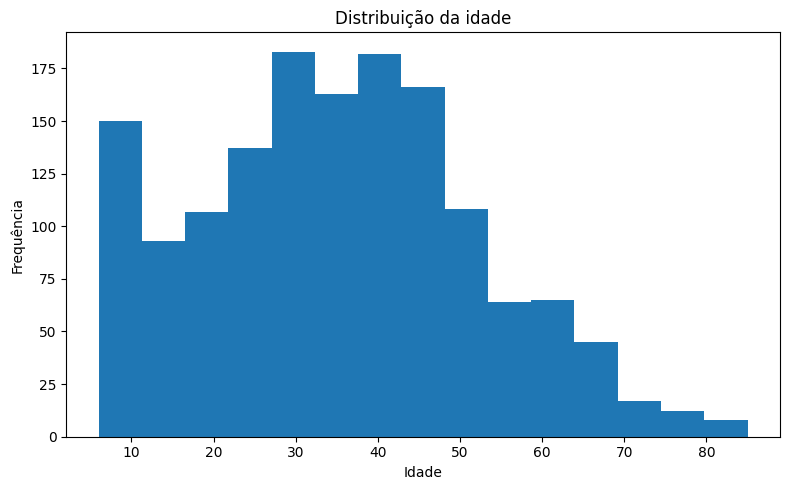

Salvo: /content/graficos_esquistossomose/01_distribuicao_idade.png


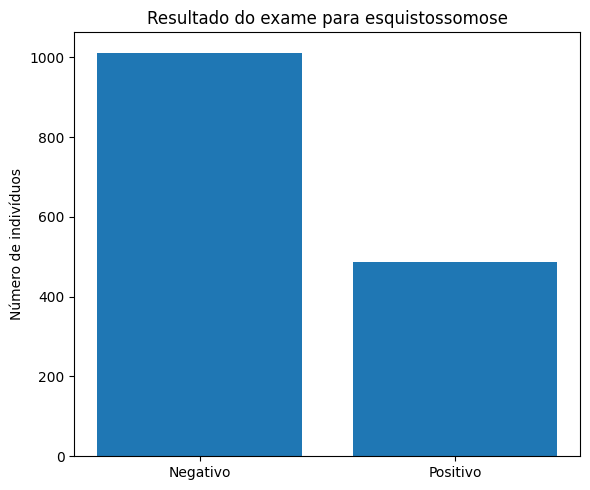

Salvo: /content/graficos_esquistossomose/02_prevalencia_geral.png


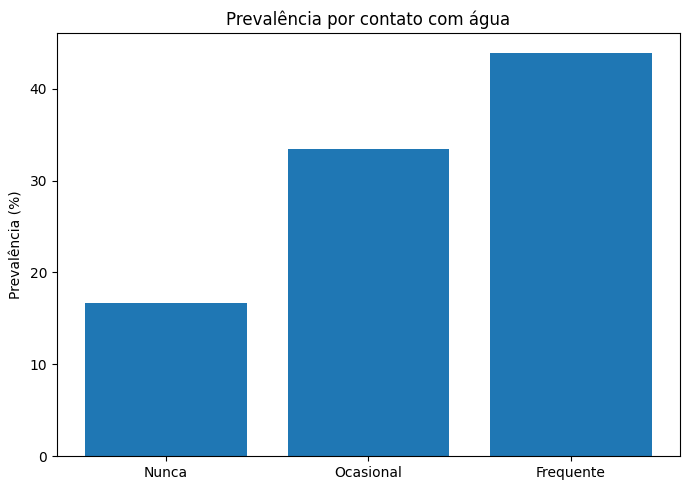

Salvo: /content/graficos_esquistossomose/03_prevalencia_contato_agua.png


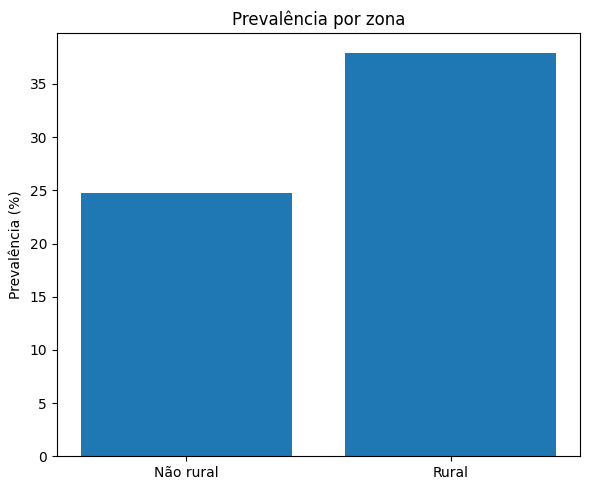

Salvo: /content/graficos_esquistossomose/04_prevalencia_zona.png


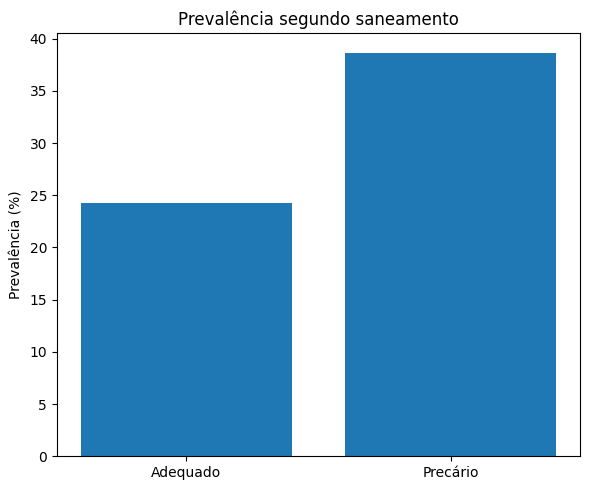

Salvo: /content/graficos_esquistossomose/05_prevalencia_saneamento.png


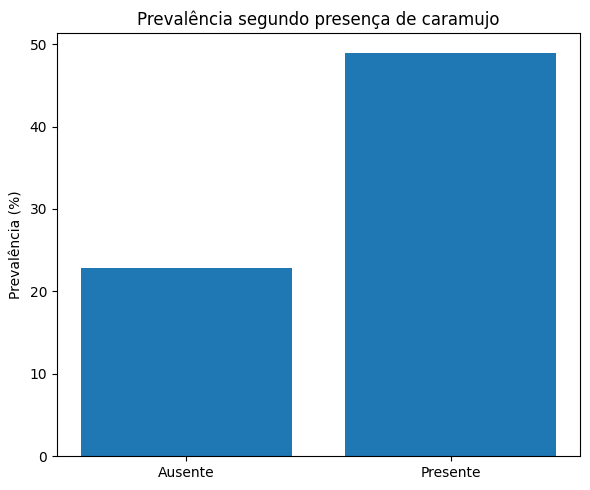

Salvo: /content/graficos_esquistossomose/06_prevalencia_caramujo.png


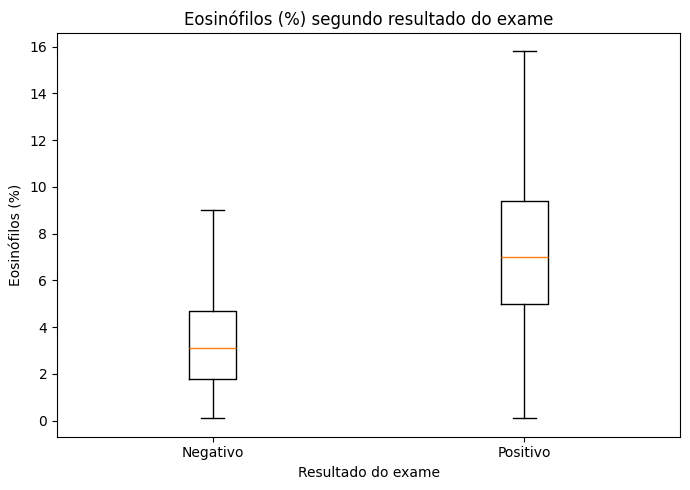

Salvo: /content/graficos_esquistossomose/07_boxplot_eosinofilos.png


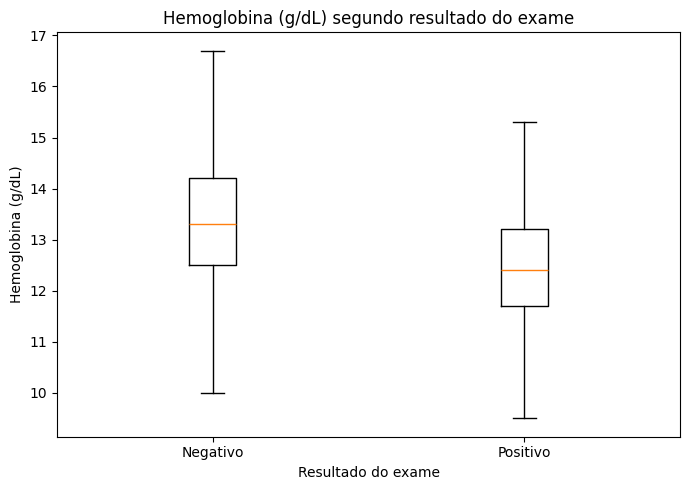

Salvo: /content/graficos_esquistossomose/08_boxplot_hemoglobina.png


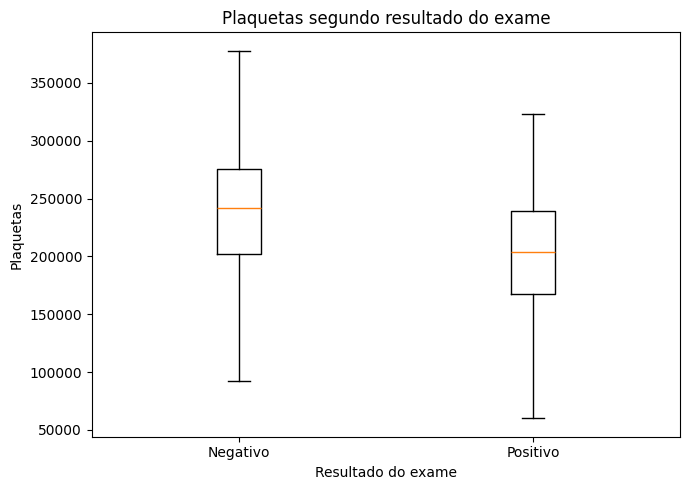

Salvo: /content/graficos_esquistossomose/09_boxplot_plaquetas.png


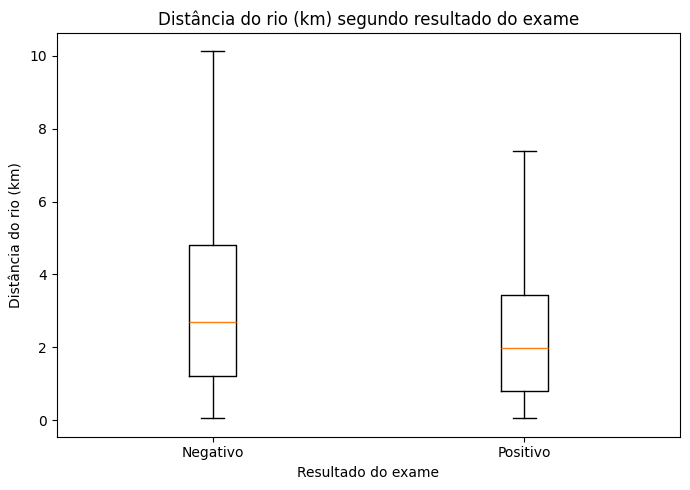

Salvo: /content/graficos_esquistossomose/10_boxplot_distancia_rio.png


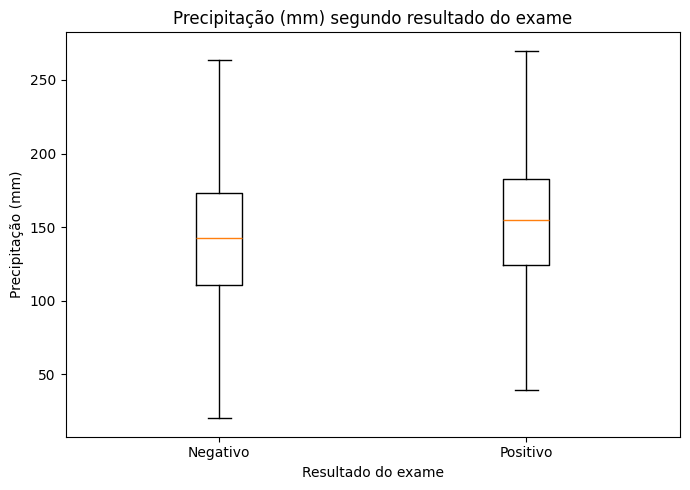

Salvo: /content/graficos_esquistossomose/11_boxplot_chuva.png


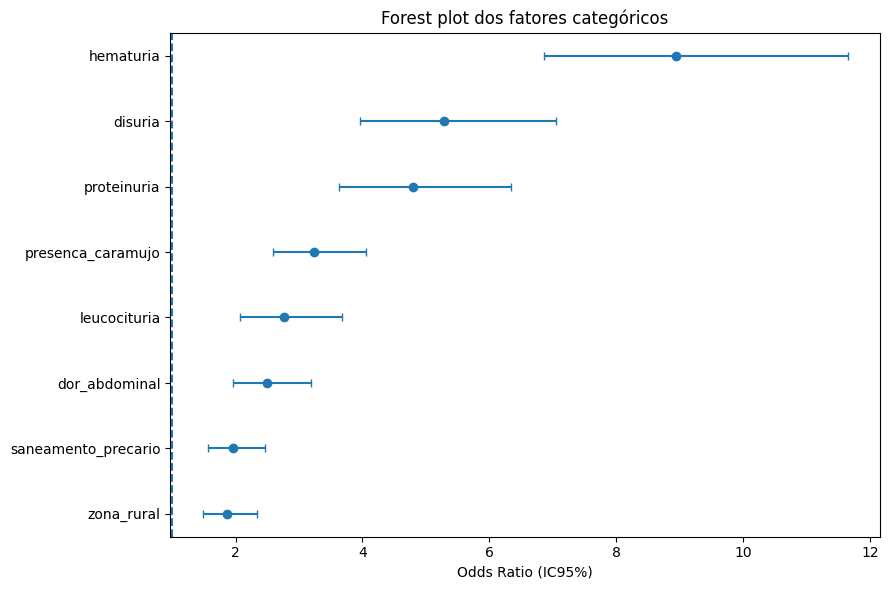

Salvo: /content/graficos_esquistossomose/12_forest_plot_odds_ratio.png


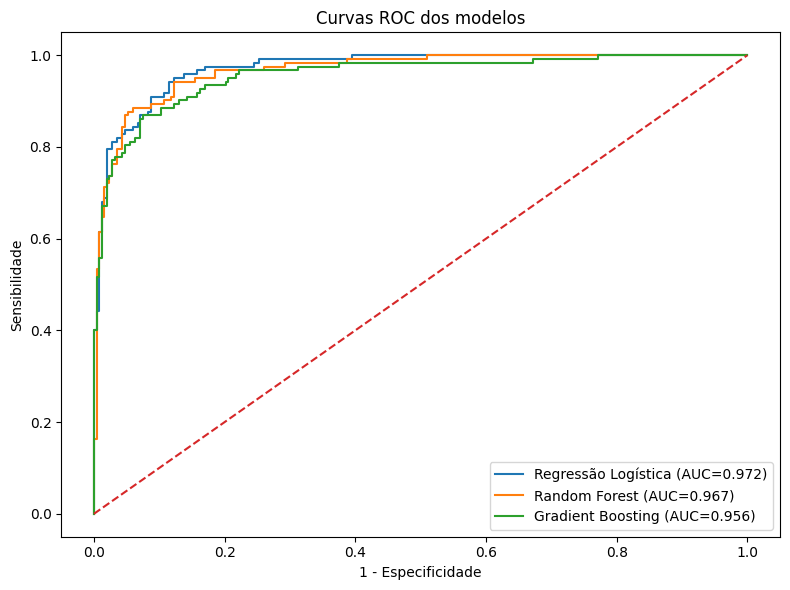

Salvo: /content/graficos_esquistossomose/13_curvas_roc.png


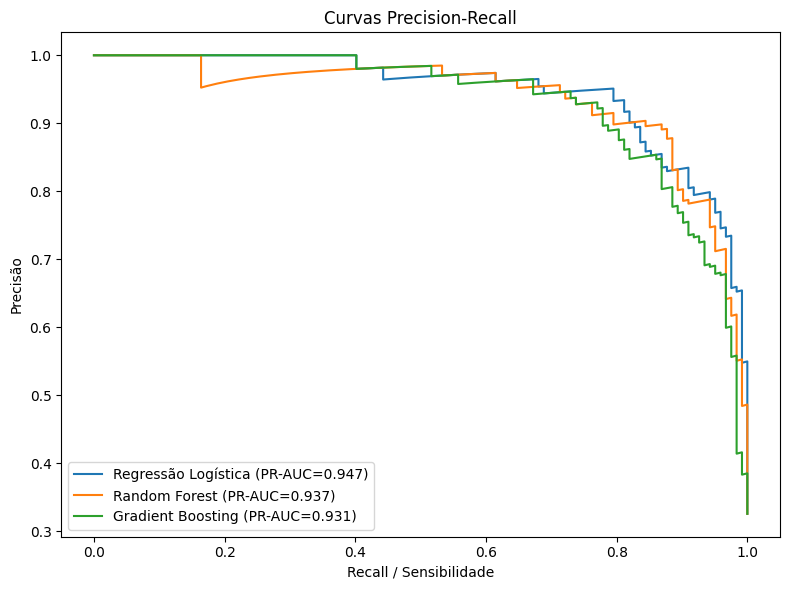

Salvo: /content/graficos_esquistossomose/14_curvas_precision_recall.png


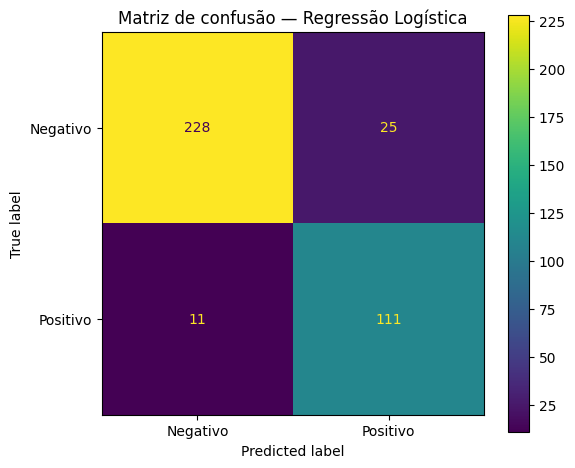

Salvo: /content/graficos_esquistossomose/15_matriz_confusao.png


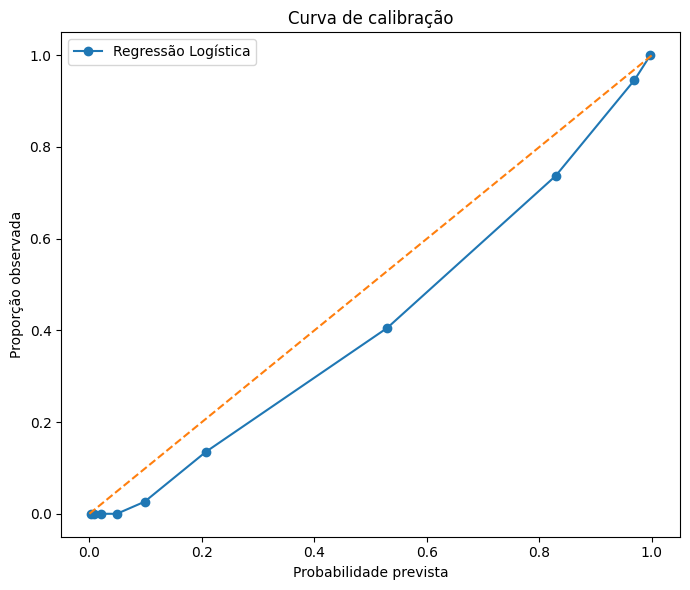

Salvo: /content/graficos_esquistossomose/16_curva_calibracao.png


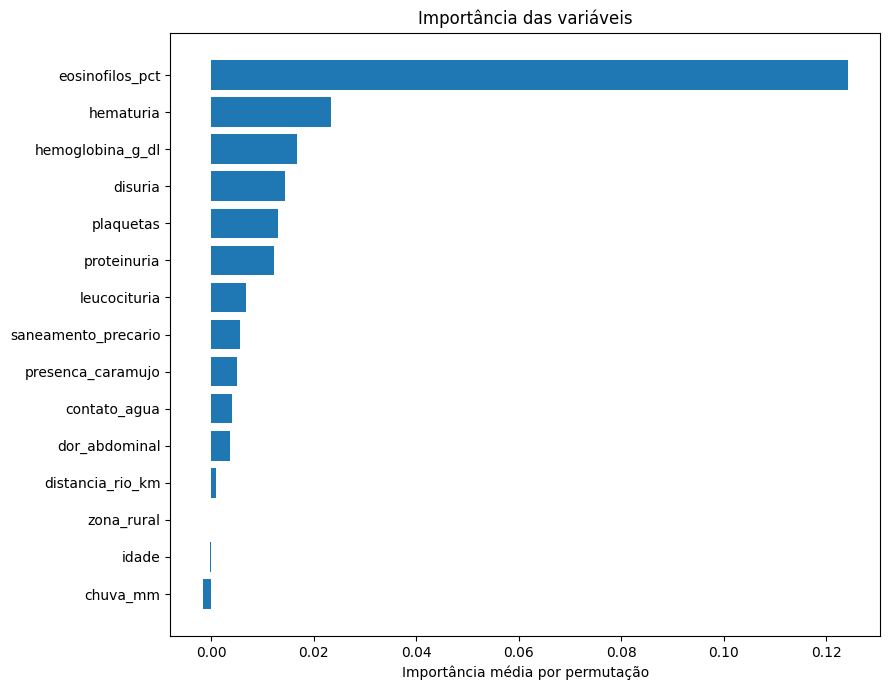

Salvo: /content/graficos_esquistossomose/17_importancia_variaveis.png


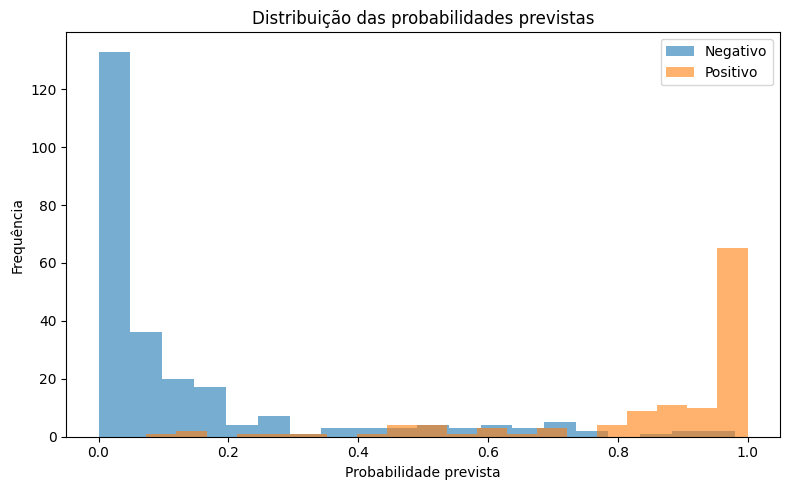

Salvo: /content/graficos_esquistossomose/18_distribuicao_probabilidades.png


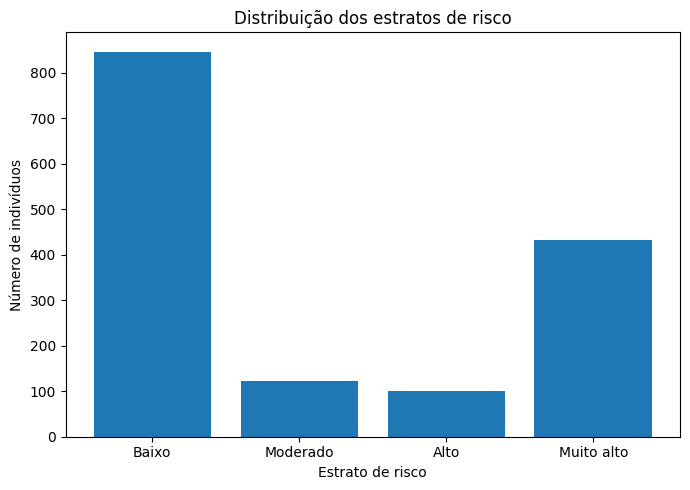

Salvo: /content/graficos_esquistossomose/19_estratos_risco.png


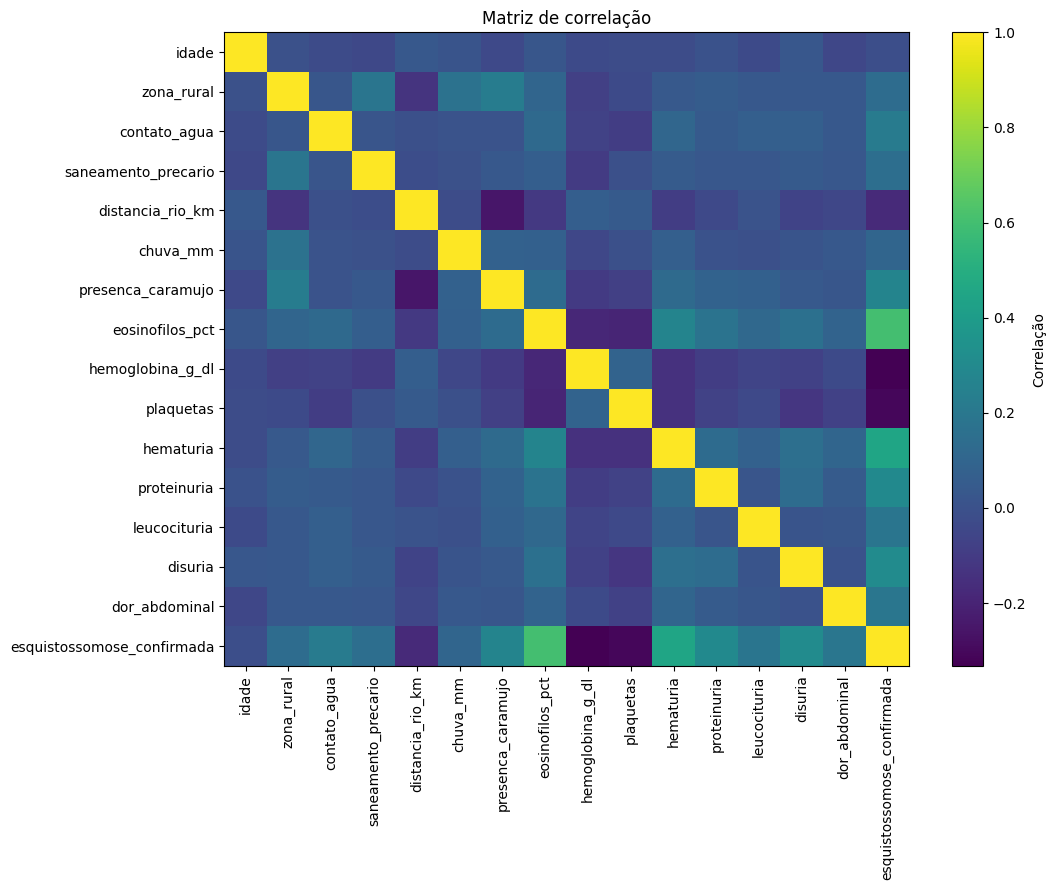

Salvo: /content/graficos_esquistossomose/20_matriz_correlacao.png

GRÁFICOS GERADOS COM SUCESSO

Pasta dos gráficos:
/content/graficos_esquistossomose

Melhor modelo por ROC-AUC: Regressão Logística
ROC-AUC: 0.9724


In [7]:
# ============================================================
# VISUALIZAÇÕES GRÁFICAS - ESQUISTOSSOMOSE
# Compatível com Google Colab
# Usa a base Excel já existente em /content
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

RANDOM_STATE = 42

BASE_DIR = Path("/content")
FIG_DIR = BASE_DIR / "graficos_esquistossomose"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ARQUIVO_EXCEL = BASE_DIR / "base_sintetica_esquistossomose_1500.xlsx"

# Procura automaticamente outro Excel se o nome for diferente.
if not ARQUIVO_EXCEL.exists():
    candidatos = [
        p for p in BASE_DIR.glob("*.xlsx")
        if not p.name.startswith("~$")
    ]

    candidatos_1500 = [
        p for p in candidatos
        if "1500" in p.name.lower()
    ]

    if candidatos_1500:
        ARQUIVO_EXCEL = candidatos_1500[0]
    elif candidatos:
        ARQUIVO_EXCEL = candidatos[0]
    else:
        raise FileNotFoundError(
            "Nenhum arquivo .xlsx foi encontrado em /content."
        )

print("=" * 70)
print("VISUALIZAÇÕES GRÁFICAS - ESQUISTOSSOMOSE")
print("=" * 70)
print(f"Base utilizada: {ARQUIVO_EXCEL}")

# ============================================================
# 2. CARREGAR BASE
# ============================================================

df = pd.read_excel(ARQUIVO_EXCEL)

print(f"Registros: {len(df)}")
print(f"Variáveis: {df.shape[1]}")

# ============================================================
# 3. VALIDAR COLUNAS
# ============================================================

colunas_necessarias = [
    "idade",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "esquistossomose_confirmada"
]

faltantes = [
    c for c in colunas_necessarias
    if c not in df.columns
]

if faltantes:
    raise ValueError(
        "Colunas ausentes:\n"
        + "\n".join(f"- {c}" for c in faltantes)
    )

for c in colunas_necessarias:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ============================================================
# FUNÇÃO AUXILIAR
# ============================================================

def salvar_e_mostrar(nome_arquivo):
    caminho = FIG_DIR / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Salvo: {caminho}")

# ============================================================
# 4. DISTRIBUIÇÃO DA IDADE
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["idade"].dropna(), bins=15)
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição da idade")
salvar_e_mostrar("01_distribuicao_idade.png")

# ============================================================
# 5. PREVALÊNCIA GERAL
# ============================================================

contagem = (
    df["esquistossomose_confirmada"]
    .value_counts()
    .reindex([0, 1])
    .fillna(0)
)

plt.figure(figsize=(6, 5))
plt.bar(["Negativo", "Positivo"], contagem.values)
plt.ylabel("Número de indivíduos")
plt.title("Resultado do exame para esquistossomose")
salvar_e_mostrar("02_prevalencia_geral.png")

# ============================================================
# 6. PREVALÊNCIA POR CONTATO COM ÁGUA
# ============================================================

prev_contato = (
    df.groupby("contato_agua")["esquistossomose_confirmada"]
    .mean()
    .reindex([0, 1, 2])
    * 100
)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Nunca", "Ocasional", "Frequente"],
    prev_contato.values
)
plt.ylabel("Prevalência (%)")
plt.title("Prevalência por contato com água")
salvar_e_mostrar("03_prevalencia_contato_agua.png")

# ============================================================
# 7. PREVALÊNCIA POR ZONA
# ============================================================

prev_zona = (
    df.groupby("zona_rural")["esquistossomose_confirmada"]
    .mean()
    .reindex([0, 1])
    * 100
)

plt.figure(figsize=(6, 5))
plt.bar(["Não rural", "Rural"], prev_zona.values)
plt.ylabel("Prevalência (%)")
plt.title("Prevalência por zona")
salvar_e_mostrar("04_prevalencia_zona.png")

# ============================================================
# 8. PREVALÊNCIA POR SANEAMENTO
# ============================================================

prev_san = (
    df.groupby("saneamento_precario")["esquistossomose_confirmada"]
    .mean()
    .reindex([0, 1])
    * 100
)

plt.figure(figsize=(6, 5))
plt.bar(["Adequado", "Precário"], prev_san.values)
plt.ylabel("Prevalência (%)")
plt.title("Prevalência segundo saneamento")
salvar_e_mostrar("05_prevalencia_saneamento.png")

# ============================================================
# 9. PREVALÊNCIA POR PRESENÇA DE CARAMUJO
# ============================================================

prev_caramujo = (
    df.groupby("presenca_caramujo")["esquistossomose_confirmada"]
    .mean()
    .reindex([0, 1])
    * 100
)

plt.figure(figsize=(6, 5))
plt.bar(["Ausente", "Presente"], prev_caramujo.values)
plt.ylabel("Prevalência (%)")
plt.title("Prevalência segundo presença de caramujo")
salvar_e_mostrar("06_prevalencia_caramujo.png")

# ============================================================
# 10. BOXPLOTS
# ============================================================

boxplots = [
    ("eosinofilos_pct", "Eosinófilos (%)", "07_boxplot_eosinofilos.png"),
    ("hemoglobina_g_dl", "Hemoglobina (g/dL)", "08_boxplot_hemoglobina.png"),
    ("plaquetas", "Plaquetas", "09_boxplot_plaquetas.png"),
    ("distancia_rio_km", "Distância do rio (km)", "10_boxplot_distancia_rio.png"),
    ("chuva_mm", "Precipitação (mm)", "11_boxplot_chuva.png")
]

for variavel, ylabel, arquivo in boxplots:
    negativo = df.loc[
        df["esquistossomose_confirmada"] == 0,
        variavel
    ].dropna()

    positivo = df.loc[
        df["esquistossomose_confirmada"] == 1,
        variavel
    ].dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [negativo, positivo],
        tick_labels=["Negativo", "Positivo"],
        showfliers=False
    )
    plt.ylabel(ylabel)
    plt.xlabel("Resultado do exame")
    plt.title(f"{ylabel} segundo resultado do exame")
    salvar_e_mostrar(arquivo)

# ============================================================
# 11. FOREST PLOT DOS ODDS RATIOS
# ============================================================

categoricas = [
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal",
    "zona_rural",
    "saneamento_precario",
    "presenca_caramujo"
]

or_rows = []

for variavel in categoricas:
    tabela = pd.crosstab(
        df[variavel],
        df["esquistossomose_confirmada"]
    )

    chi2, p, _, _ = chi2_contingency(tabela)

    a = ((df[variavel] == 1) & (df["esquistossomose_confirmada"] == 1)).sum()
    b = ((df[variavel] == 1) & (df["esquistossomose_confirmada"] == 0)).sum()
    c = ((df[variavel] == 0) & (df["esquistossomose_confirmada"] == 1)).sum()
    d = ((df[variavel] == 0) & (df["esquistossomose_confirmada"] == 0)).sum()

    if min(a, b, c, d) == 0:
        a += 0.5
        b += 0.5
        c += 0.5
        d += 0.5

    OR = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    lo, hi = np.exp(
        np.log(OR) + np.array([-1, 1]) * 1.96 * se
    )

    or_rows.append({
        "variavel": variavel,
        "odds_ratio": OR,
        "IC95_inf": lo,
        "IC95_sup": hi,
        "p_valor": p
    })

or_df = pd.DataFrame(or_rows).sort_values("odds_ratio")

y_pos = np.arange(len(or_df))

xerr = np.vstack([
    or_df["odds_ratio"] - or_df["IC95_inf"],
    or_df["IC95_sup"] - or_df["odds_ratio"]
])

plt.figure(figsize=(9, 6))
plt.errorbar(
    or_df["odds_ratio"],
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=3
)
plt.axvline(1, linestyle="--")
plt.yticks(y_pos, or_df["variavel"])
plt.xlabel("Odds Ratio (IC95%)")
plt.title("Forest plot dos fatores categóricos")
salvar_e_mostrar("12_forest_plot_odds_ratio.png")

# ============================================================
# 12. MODELAGEM
# ============================================================

features = [
    "idade",
    "zona_rural",
    "contato_agua",
    "saneamento_precario",
    "distancia_rio_km",
    "chuva_mm",
    "presenca_caramujo",
    "eosinofilos_pct",
    "hemoglobina_g_dl",
    "plaquetas",
    "hematuria",
    "proteinuria",
    "leucocituria",
    "disuria",
    "dor_abdominal"
]

data_ml = df[
    features + ["esquistossomose_confirmada"]
].dropna()

X = data_ml[features]
y = data_ml["esquistossomose_confirmada"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=300,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )
}

predicoes = {}
modelos_treinados = {}
metricas = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_treinados[nome] = modelo

    prob = modelo.predict_proba(X_test)[:, 1]
    predicoes[nome] = prob

    metricas.append({
        "modelo": nome,
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    })

metricas_df = pd.DataFrame(metricas).sort_values(
    "ROC_AUC",
    ascending=False
)

melhor_nome = metricas_df.iloc[0]["modelo"]
melhor_modelo = modelos_treinados[melhor_nome]
melhor_prob = predicoes[melhor_nome]

# ============================================================
# 13. CURVAS ROC
# ============================================================

plt.figure(figsize=(8, 6))

for nome, prob in predicoes.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{nome} (AUC={auc_val:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("1 - Especificidade")
plt.ylabel("Sensibilidade")
plt.title("Curvas ROC dos modelos")
plt.legend()
salvar_e_mostrar("13_curvas_roc.png")

# ============================================================
# 14. CURVAS PRECISION-RECALL
# ============================================================

plt.figure(figsize=(8, 6))

for nome, prob in predicoes.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        prob
    )

    pr_auc = average_precision_score(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{nome} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall / Sensibilidade")
plt.ylabel("Precisão")
plt.title("Curvas Precision-Recall")
plt.legend()
salvar_e_mostrar("14_curvas_precision_recall.png")

# ============================================================
# 15. MATRIZ DE CONFUSÃO
# ============================================================

melhor_pred = (
    melhor_prob >= 0.50
).astype(int)

cm = confusion_matrix(
    y_test,
    melhor_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
ax.set_title(f"Matriz de confusão — {melhor_nome}")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "15_matriz_confusao.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()
print(f"Salvo: {FIG_DIR / '15_matriz_confusao.png'}")

# ============================================================
# 16. CURVA DE CALIBRAÇÃO
# ============================================================

prob_true, prob_pred = calibration_curve(
    y_test,
    melhor_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label=melhor_nome
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Proporção observada")
plt.title("Curva de calibração")
plt.legend()
salvar_e_mostrar("16_curva_calibracao.png")

# ============================================================
# 17. IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

perm = permutation_importance(
    melhor_modelo,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

imp = pd.DataFrame({
    "variavel": features,
    "importancia_media": perm.importances_mean
}).sort_values(
    "importancia_media",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    imp["variavel"],
    imp["importancia_media"]
)
plt.xlabel("Importância média por permutação")
plt.title("Importância das variáveis")
salvar_e_mostrar("17_importancia_variaveis.png")

# ============================================================
# 18. DISTRIBUIÇÃO DAS PROBABILIDADES
# ============================================================

y_test_arr = y_test.to_numpy()

plt.figure(figsize=(8, 5))

plt.hist(
    melhor_prob[y_test_arr == 0],
    bins=20,
    alpha=0.6,
    label="Negativo"
)

plt.hist(
    melhor_prob[y_test_arr == 1],
    bins=20,
    alpha=0.6,
    label="Positivo"
)

plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência")
plt.title("Distribuição das probabilidades previstas")
plt.legend()
salvar_e_mostrar("18_distribuicao_probabilidades.png")

# ============================================================
# 19. ESTRATOS DE RISCO
# ============================================================

mask = df[features].notna().all(axis=1)

df["probabilidade_modelo"] = np.nan

df.loc[
    mask,
    "probabilidade_modelo"
] = melhor_modelo.predict_proba(
    df.loc[mask, features]
)[:, 1]

df["estrato_risco"] = pd.cut(
    df["probabilidade_modelo"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.0],
    labels=["Baixo", "Moderado", "Alto", "Muito alto"]
)

ordem_risco = [
    "Baixo",
    "Moderado",
    "Alto",
    "Muito alto"
]

risco = (
    df["estrato_risco"]
    .value_counts()
    .reindex(ordem_risco)
    .fillna(0)
)

plt.figure(figsize=(7, 5))
plt.bar(ordem_risco, risco.values)
plt.xlabel("Estrato de risco")
plt.ylabel("Número de indivíduos")
plt.title("Distribuição dos estratos de risco")
salvar_e_mostrar("19_estratos_risco.png")

# ============================================================
# 20. MATRIZ DE CORRELAÇÃO
# ============================================================

corr_vars = features + [
    "esquistossomose_confirmada"
]

corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    corr,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(corr.columns))
)

ax.set_yticks(
    np.arange(len(corr.index))
)

ax.set_xticklabels(
    corr.columns,
    rotation=90
)

ax.set_yticklabels(
    corr.index
)

fig.colorbar(
    im,
    ax=ax,
    label="Correlação"
)

ax.set_title(
    "Matriz de correlação"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "20_matriz_correlacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Salvo: {FIG_DIR / '20_matriz_correlacao.png'}")

# ============================================================
# 21. FINAL
# ============================================================

print("\n" + "=" * 70)
print("GRÁFICOS GERADOS COM SUCESSO")
print("=" * 70)

print(f"\nPasta dos gráficos:\n{FIG_DIR}")

print(
    "\nMelhor modelo por ROC-AUC: "
    f"{melhor_nome}"
)

print(
    f"ROC-AUC: "
    f"{metricas_df.iloc[0]['ROC_AUC']:.4f}"
)
